In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("software_assets_data.csv", index_col=None)

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [ ]:
data.head(5)

,software_version,other_software_Version,software_compatbile,software_compatbile_count,new_requirements,operate_cost,defect_count,slo_misses,other_sw_version_defect_count,other_sw_invest_cost,upgrade_cost
0,Java 6,Oracle Database 10g,Yes,1,1,2000,2,12,2,1250,675000
1,Java 6,Oracle Database 11g,Yes,1,1,1185,3,104,3,2465,765000
2,Java 7,Oracle Database 11g,Yes,1,1,2143,4,12,4,2500,819000
3,Java 7,Oracle Database 12c,Yes,1,1,2500,2,105,2,2701,453150
4,Java 8,Oracle Database 11g,No,0,1,1275,3,97,3,2850,480000


In [ ]:
data.columns

Index(['software_version', 'other_software_Version', 'software_compatbile',
       'software_compatbile_count', 'new_requirements', 'operate_cost',
       'defect_count', 'slo_misses', 'other_sw_version_defect_count',
       'other_sw_invest_cost', 'upgrade_cost'],
      dtype='object')

In [ ]:
data.describe().round(2)

,software_compatbile_count,new_requirements,operate_cost,defect_count,slo_misses,other_sw_version_defect_count,other_sw_invest_cost,upgrade_cost
count,243.00,243.00,243.00,243.00,243.00,243.00,243.00,243.00
mean,0.77,1.85,2424.30,7.62,67.45,7.62,2477.21,538379.34
std,0.42,0.59,732.09,1.24,33.03,1.24,739.43,100794.65
min,0.00,1.00,709.00,2.00,1.00,2.00,709.00,415000.00
25%,1.00,1.00,1958.50,8.00,52.00,8.00,1997.50,454500.00
50%,1.00,2.00,2375.00,8.00,67.00,8.00,2424.00,515000.00
75%,1.00,2.00,2650.50,8.00,94.50,8.00,2679.00,605000.00
max,1.00,3.00,4750.00,9.00,118.00,9.00,4878.00,819000.00


In [ ]:
data.describe(include='object').T

,count,unique,top,freq
software_version,243,47,Python 2.7,13
other_software_Version,243,34,MySQL 8.0,23
software_compatbile,243,2,Yes,186


In [ ]:
data.drop(['software_version','other_software_Version','software_compatbile'],axis=1,inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   software_compatbile_count      243 non-null    int64
 1   new_requirements               243 non-null    int64
 2   operate_cost                   243 non-null    int64
 3   defect_count                   243 non-null    int64
 4   slo_misses                     243 non-null    int64
 5   other_sw_version_defect_count  243 non-null    int64
 6   other_sw_invest_cost           243 non-null    int64
 7   upgrade_cost                   243 non-null    int64
dtypes: int64(8)
memory usage: 15.3 KB


In [ ]:
dups = data.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

Number of duplicate rows = 0


In [ ]:
data.isnull().sum()

,0
software_compatbile_count,0
new_requirements,0
operate_cost,0
defect_count,0
slo_misses,0
other_sw_version_defect_count,0
other_sw_invest_cost,0
upgrade_cost,0


In [ ]:
data[data.isnull().any(axis=1)]

,software_compatbile_count,new_requirements,operate_cost,defect_count,slo_misses,other_sw_version_defect_count,other_sw_invest_cost,upgrade_cost


In [ ]:
data.dropna(inplace=True) # We have a blank row in the dataset
data.isnull().sum()

,0
software_compatbile_count,0
new_requirements,0
operate_cost,0
defect_count,0
slo_misses,0
other_sw_version_defect_count,0
other_sw_invest_cost,0
upgrade_cost,0


#### Univariate analysis-

In [ ]:
data.columns


Index(['software_compatbile_count', 'new_requirements', 'operate_cost',
       'defect_count', 'slo_misses', 'other_sw_version_defect_count',
       'other_sw_invest_cost', 'upgrade_cost'],
      dtype='object')

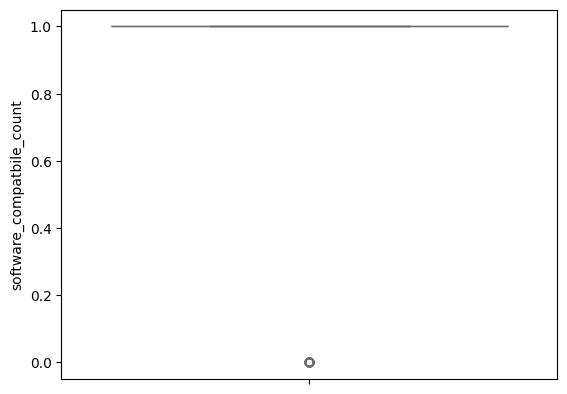

In [ ]:
sns.boxplot(data['software_compatbile_count'], color="violet")
plt.show()

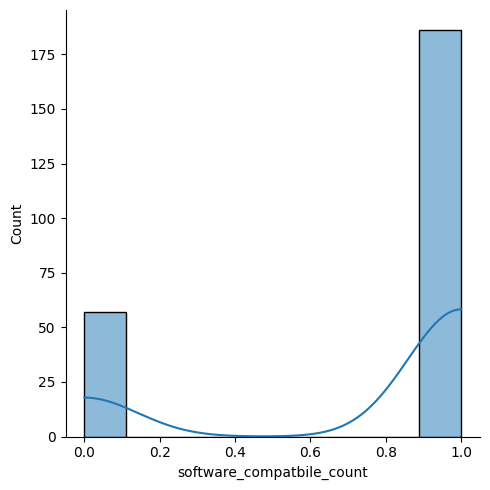

In [ ]:
sns.displot(data['software_compatbile_count'],kde=True)
plt.show()

In [ ]:
data['software_compatbile_count'].describe()

,software_compatbile_count
count,243.000000
mean,0.765432
std,0.424603
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


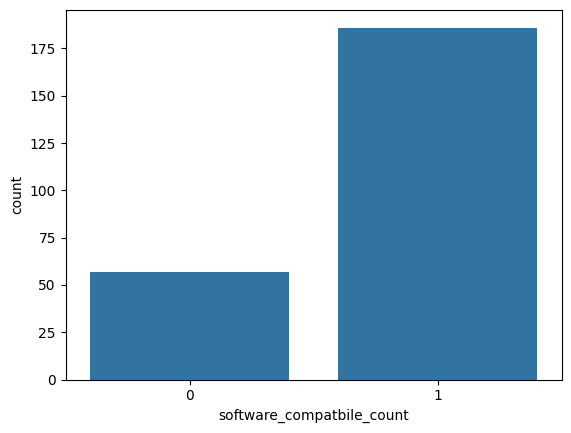

In [ ]:
sns.countplot(x= data.software_compatbile_count)
plt.show()

In [ ]:
data.software_compatbile_count.value_counts()

,count
software_compatbile_count,
1,186
0,57


### 1. New requirements

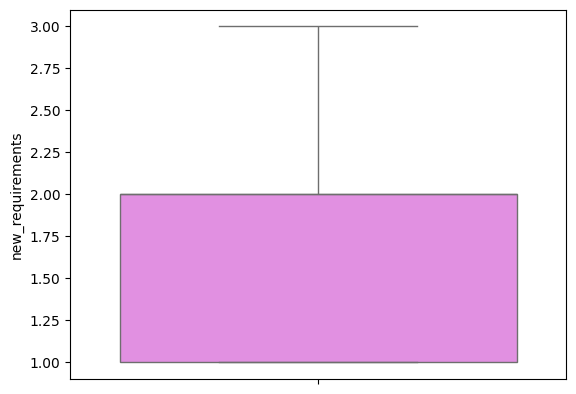

In [ ]:
sns.boxplot(data['new_requirements'], color="violet")
plt.show()


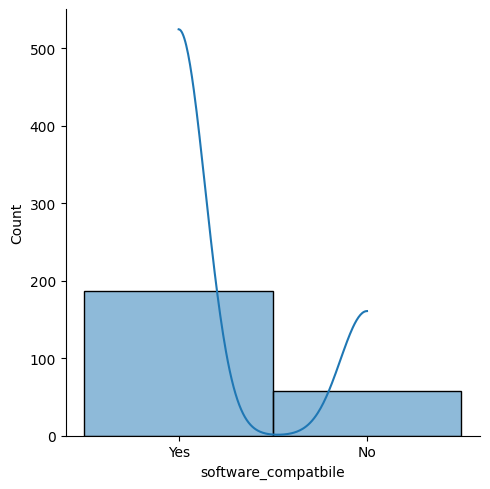

In [ ]:
sns.displot(data['software_compatbile'],kde=True)
plt.show()

In [ ]:
data['new_requirements'].describe()

,new_requirements
count,243.000000
mean,1.847737
std,0.586932
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,3.000000


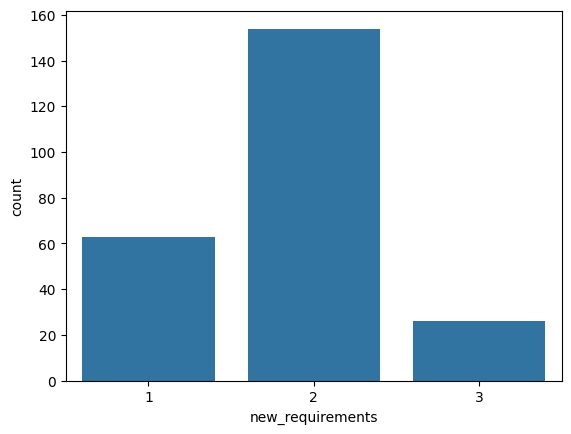

In [ ]:
sns.countplot(x= data['new_requirements'])
plt.show()

### 2. Open defect count

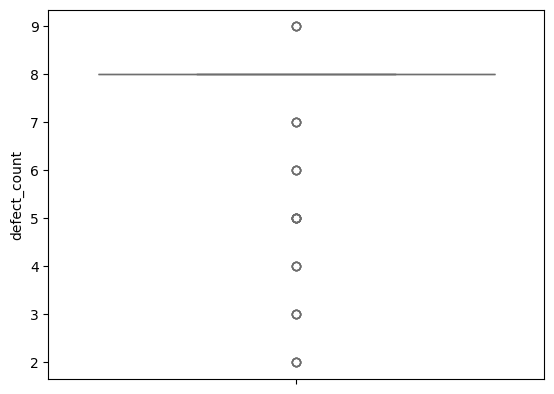

In [ ]:
sns.boxplot(data['defect_count'], color="violet")
plt.show()


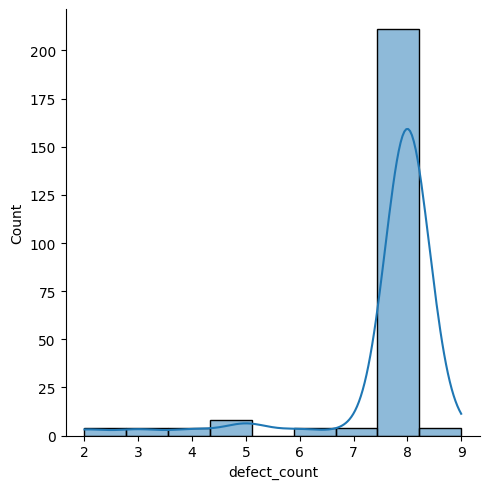

In [ ]:
sns.displot(data['defect_count'],kde=True)
plt.show()

In [ ]:
data['defect_count'].describe()

,defect_count
count,243.000000
mean,7.621399
std,1.235108
min,2.000000
25%,8.000000
50%,8.000000
75%,8.000000
max,9.000000


### 3. upgrade_cost

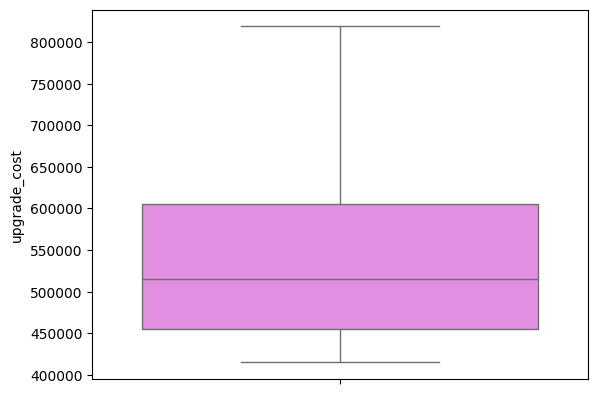

In [ ]:
sns.boxplot(data['upgrade_cost'], color="violet")
plt.show()


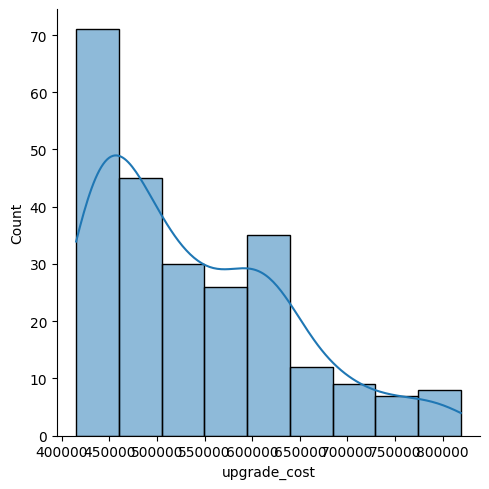

In [ ]:
sns.displot(data['upgrade_cost'],kde=True)
plt.show()

In [ ]:
data['upgrade_cost'].describe()

,upgrade_cost
count,243.000000
mean,538379.341564
std,100794.650803
min,415000.000000
25%,454500.000000
50%,515000.000000
75%,605000.000000
max,819000.000000


### 4. Operate cost

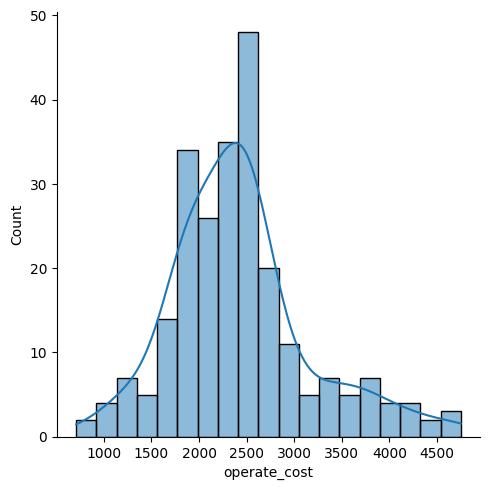

In [ ]:
sns.displot(data['operate_cost'],kde=True)
plt.show()


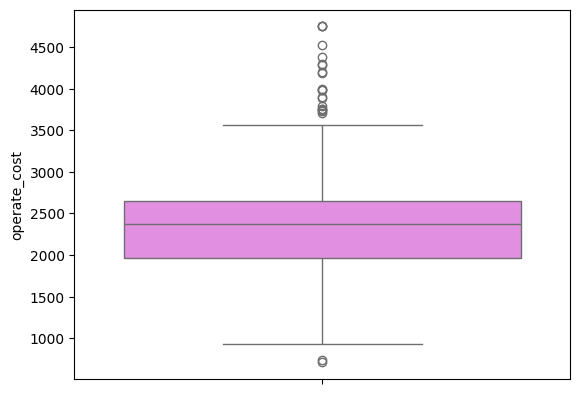

In [ ]:
sns.boxplot(data['operate_cost'], color="violet")
plt.show()


In [ ]:
data['operate_cost'].describe()

,operate_cost
count,243.000000
mean,2424.304527
std,732.087831
min,709.000000
25%,1958.500000
50%,2375.000000
75%,2650.500000
max,4750.000000


### 5. SLO misses

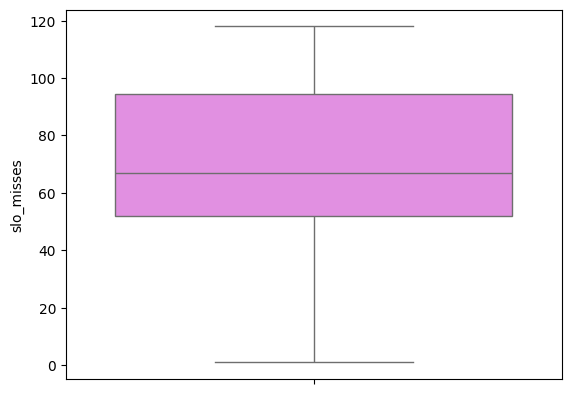

In [ ]:
sns.boxplot( data['slo_misses'], color="violet")
plt.show()

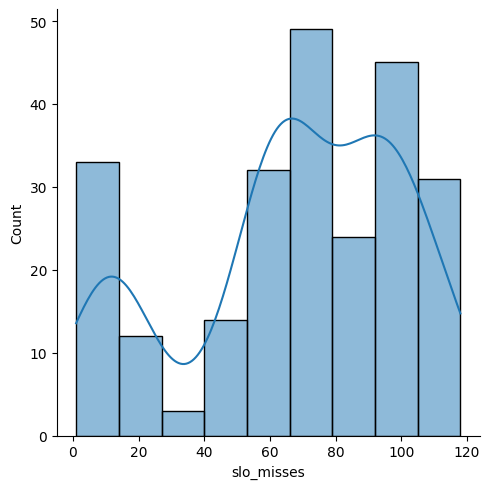

In [ ]:
sns.displot( data['slo_misses'],kde=True)
plt.show()

In [ ]:
data['slo_misses'].describe()

,slo_misses
count,243.000000
mean,67.452675
std,33.033429
min,1.000000
25%,52.000000
50%,67.000000
75%,94.500000
max,118.000000


### 6. other software version defect count

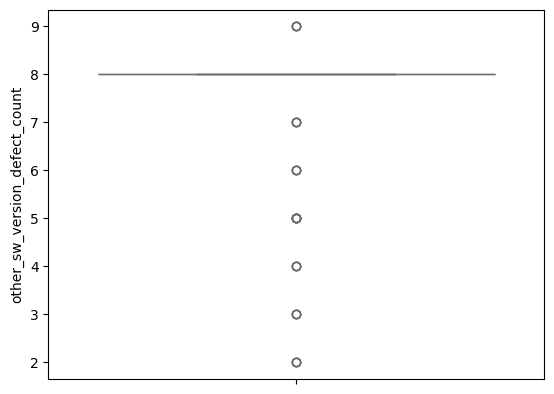

In [ ]:
sns.boxplot( data['other_sw_version_defect_count'], color="violet")
plt.show()

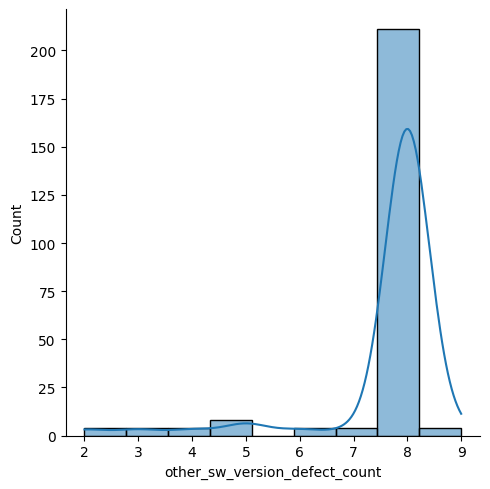

In [ ]:
sns.displot( data['other_sw_version_defect_count'],kde=True)
plt.show()

In [ ]:
data['other_sw_version_defect_count'].describe()

,other_sw_version_defect_count
count,243.000000
mean,7.621399
std,1.235108
min,2.000000
25%,8.000000
50%,8.000000
75%,8.000000
max,9.000000


##### 7. Other software invest count

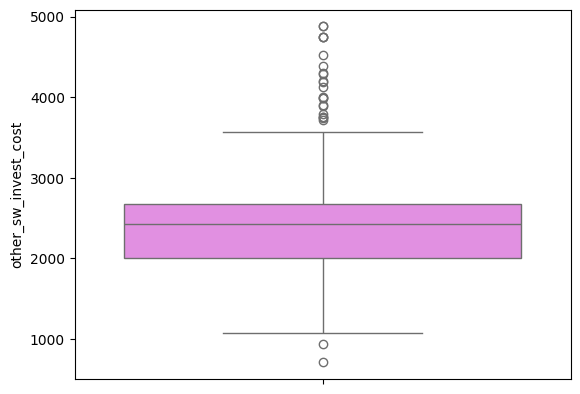

In [ ]:
sns.boxplot( data['other_sw_invest_cost'], color="violet")
plt.show()

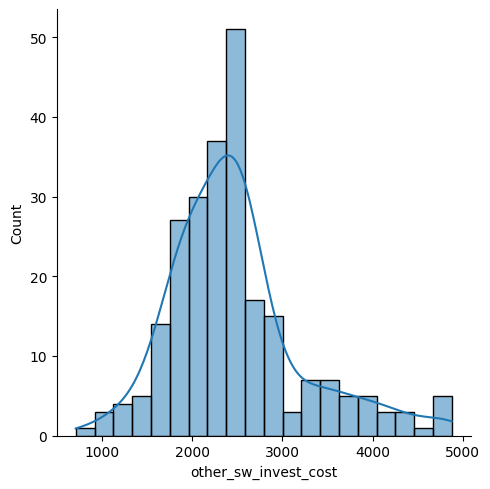

In [ ]:
sns.displot( data['other_sw_invest_cost'],kde=True)
plt.show()

In [ ]:
data['other_sw_invest_cost'].describe()

,other_sw_invest_cost
count,243.000000
mean,2477.213992
std,739.431334
min,709.000000
25%,1997.500000
50%,2424.000000
75%,2679.000000
max,4878.000000


### Analysis of Variation -
The coefficient of variation (relative standard deviation) is a statistical measure of the dispersion of data points around the mean. Higher value indicates greater spread. It can be used to compare variation among data series with different means.

In [ ]:
CV_data = pd.DataFrame(data = [data.std().values,data.mean().values,data.std().values/data.mean().values] , columns=data.columns , index = ['Std Dev','Mean','CV'] ).T

In [ ]:
CV_data.sort_values(by='CV',ascending=False).round(3)

,Std Dev,Mean,CV
software_compatbile_count,0.425,0.765,0.555
slo_misses,33.033,67.453,0.490
new_requirements,0.587,1.848,0.318
operate_cost,732.088,2424.305,0.302
other_sw_invest_cost,739.431,2477.214,0.298
upgrade_cost,100794.651,538379.342,0.187
defect_count,1.235,7.621,0.162
other_sw_version_defect_count,1.235,7.621,0.162


software compatible count has the highest value of Coeffecient of Variation at 0.555, while defect count of softwares have the lowest CV of 0.162.

### Percentage Outliers -

In [ ]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
pd.DataFrame((((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()/data.shape[0]*100).round(2),columns=['Outliers %'])

,Outliers %
software_compatbile_count,23.46
new_requirements,0.00
operate_cost,9.05
defect_count,13.17
slo_misses,0.00
other_sw_version_defect_count,13.17
other_sw_invest_cost,9.88
upgrade_cost,0.00


As the percentage outliers are very low (2.62% being the highest), we will not be doing outlier treatment or removal for the current analysis. An outlier percentage of order of 15-20% is a cause for concern thus must be thoroughly investigated.

### Multivariate Analysis -

### Pair plot-
A pairs plot allows us to see both distribution of single variables and relationships between two variables. Pair plots are a great method to identify trends for follow-up analysis. The histogram on the diagonal allows us to see the distribution of a single variable while the scatter plots on the upper and lower triangles show the relationship (or lack thereof) between two variables.

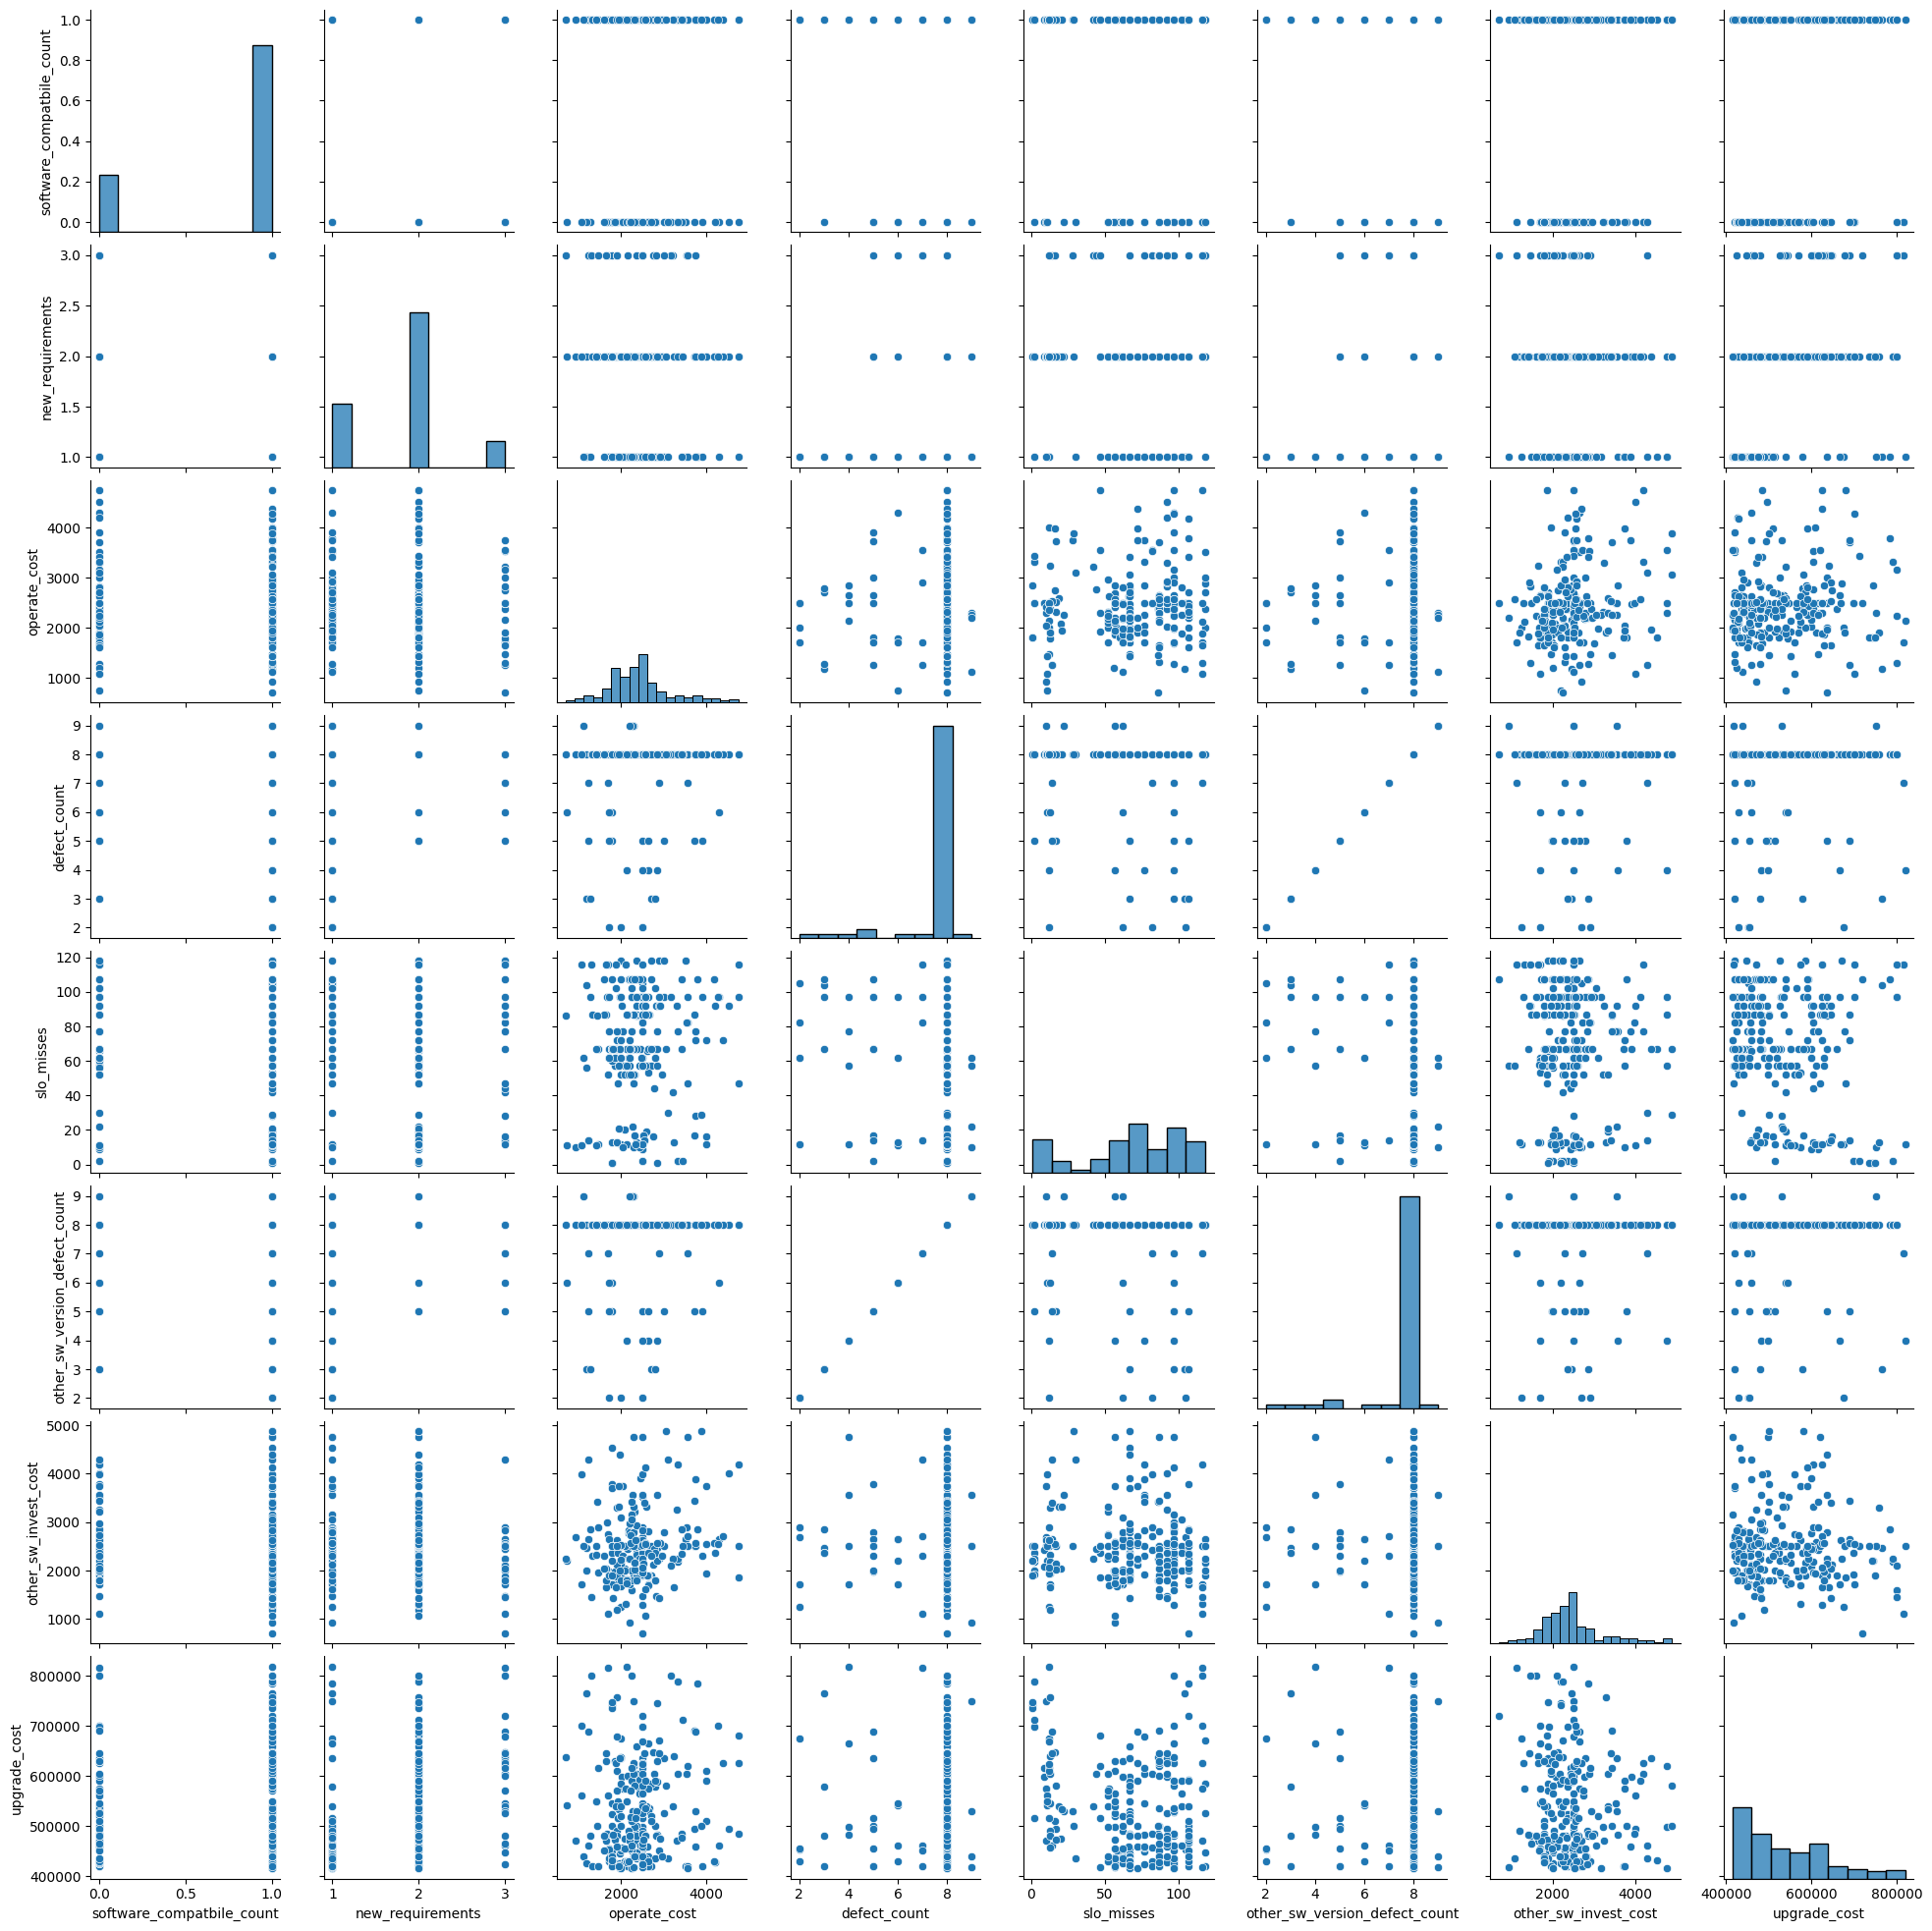

In [ ]:
sns.pairplot(data)
plt.show()

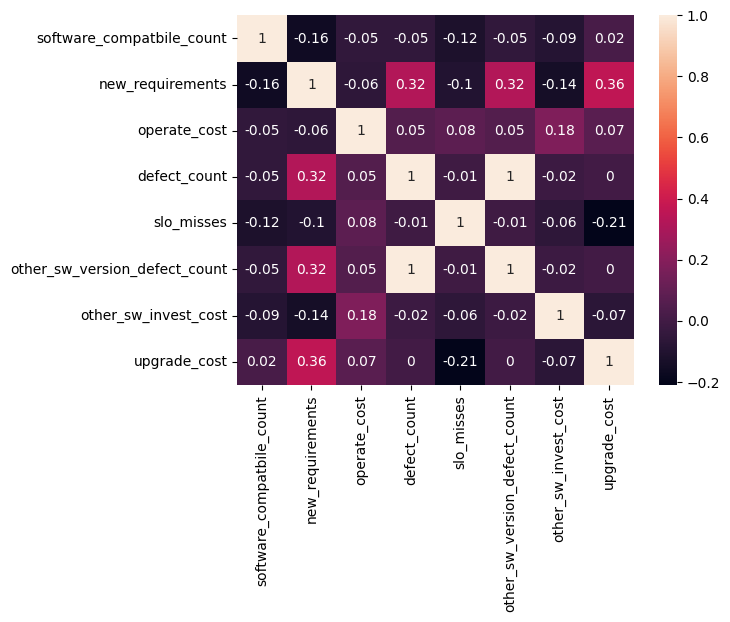

In [ ]:
cor = data.corr().round(2)
sns.heatmap(cor, annot=True)
plt.show()

### Inferences-

Top Positive Correlation Pairs  -
1. new_requirements and operate_cost (0.36, 0.07)
2. software_compatible_cost (0.02)
3. defect counts (o correlation)

Negative correlations are not significant, highest being -0.21 of slo_misses

As we have seen, we have few pairs of features with significant positive correlations. We will perform Principal Component Analysis to handle the issue of Multicollinearity. PCA is also useful when the features are too many, and we want to reduce the feature set without losing a significant amount of information (variability).

Lets first train a Linear Regression model on original features, and then compare the model perfromance with a Model trained on Optimum no. of Principal Components.

### Linear Regression Model with original features -

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = data.drop(['new_requirements'],axis=1)
y = data['new_requirements']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=10,test_size=0.2)

In [ ]:
X_train.shape,X_test.shape

((194, 7), (49, 7))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
LR = LinearRegression()
LR.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_train_pred = LR.predict(X_train)

In [ ]:
y_test_pred = LR.predict(X_test)

### RMSE values -

In [ ]:
np.sqrt(mean_squared_error(y_true = y_train, y_pred =y_train_pred )).round(3)

0.531

In [ ]:
np.sqrt(mean_squared_error(y_true = y_test, y_pred =y_test_pred )).round(3)

0.337

### R^2 Scores -

In [ ]:
r2_score(y_true = y_train, y_pred =y_train_pred )

0.261280276444235

In [ ]:
r2_score(y_true = y_test, y_pred =y_test_pred )

0.4055613874359303

### Adj. R2 Scores -

<img src="http://www.haghish.com/statistics/stata-blog/stata-programming/images/adjr2.png" width="400" height="200" />

##### For Train Set-

In [ ]:
n = X_train.shape[0]
k = X_train.shape[1]
r2 = r2_score(y_true = y_train, y_pred =y_train_pred )

In [ ]:
1 - ((1- r2)*(n-1)/(n-k-1))

0.23347899652546966

##### For Test Set-

In [ ]:
n = X_test.shape[0]
k = X_test.shape[1]
r2 = r2_score(y_true = y_test, y_pred =y_test_pred )

In [ ]:
1 - ((1- r2)*(n-1)/(n-k-1))

0.3040718682176745

We have obtained R2 scores of 0.26 and 0.40 on both Train and Test set, thus the model is not so performing well on unseen data (test data) as it does on the training data.


# Regularization techniques

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
ridge = Ridge(alpha = 0.1)
lasso = Lasso(alpha = 0.1)
elasticnet = ElasticNet(l1_ratio=0.5,alpha = 0.0001)

### Ridge model

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'software_compatbile_count'),
  Text(1, 0, 'operate_cost'),
  Text(2, 0, 'defect_count'),
  Text(3, 0, 'slo_misses'),
  Text(4, 0, 'other_sw_version_defect_count'),
  Text(5, 0, 'other_sw_invest_cost'),
  Text(6, 0, 'upgrade_cost')])

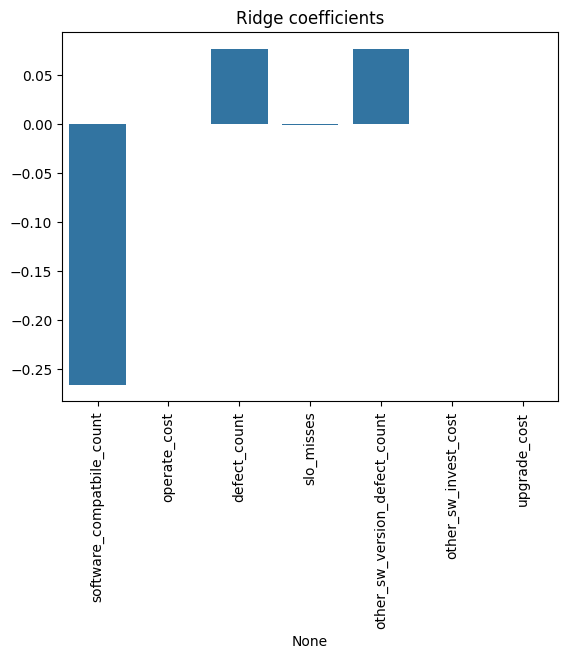

In [ ]:
model = ridge.fit(X_train,y_train)
sns.barplot(x = X_train.columns,y = model.coef_)
plt.title('Ridge coefficients')
plt.xticks(rotation = 90)

### Lasso model

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'software_compatbile_count'),
  Text(1, 0, 'operate_cost'),
  Text(2, 0, 'defect_count'),
  Text(3, 0, 'slo_misses'),
  Text(4, 0, 'other_sw_version_defect_count'),
  Text(5, 0, 'other_sw_invest_cost'),
  Text(6, 0, 'upgrade_cost')])

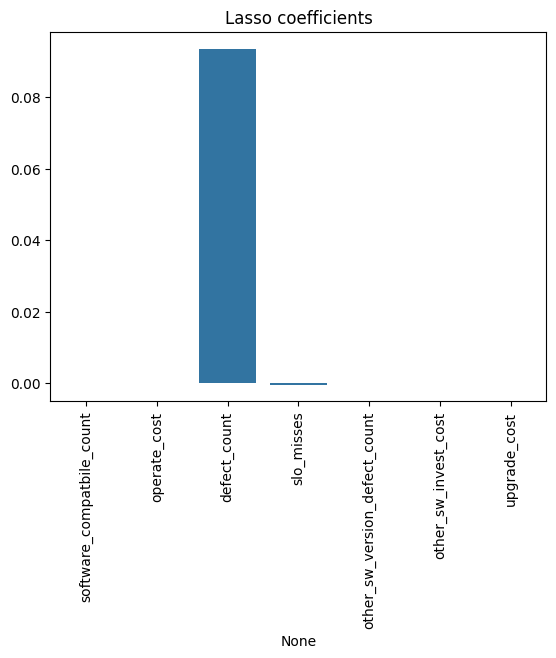

In [ ]:
model = lasso.fit(X_train,y_train)
sns.barplot(x = X_train.columns,y = model.coef_)
plt.title('Lasso coefficients')
plt.xticks(rotation = 90)

### Elasticnet model

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'software_compatbile_count'),
  Text(1, 0, 'operate_cost'),
  Text(2, 0, 'defect_count'),
  Text(3, 0, 'slo_misses'),
  Text(4, 0, 'other_sw_version_defect_count'),
  Text(5, 0, 'other_sw_invest_cost'),
  Text(6, 0, 'upgrade_cost')])

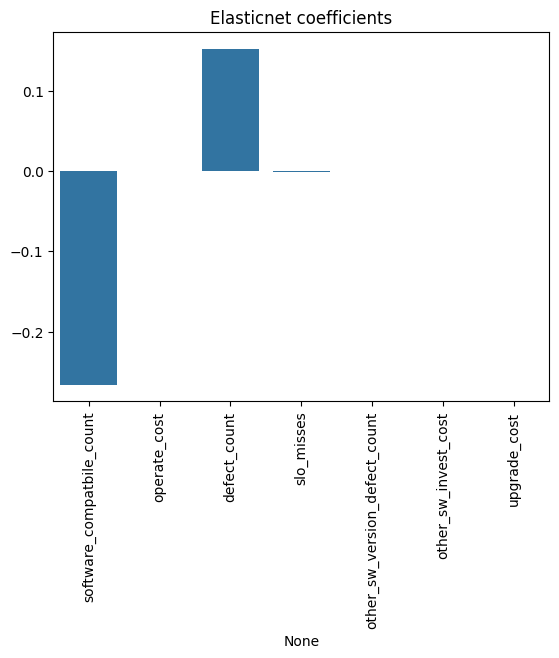

In [ ]:
model = elasticnet.fit(X_train,y_train)
sns.barplot(x = X_train.columns,y = model.coef_)
plt.title('Elasticnet coefficients')
plt.xticks(rotation = 90)

### K-fold cross validation

In [ ]:
from sklearn.model_selection import KFold
from sklearn import metrics
kf = KFold(n_splits=10,shuffle=True,random_state=0)
for model,name in zip([LR,ridge,lasso,elasticnet],['Linear_Regression','Ridge','LASSO','ElasticNet']):
    rmse = []
    for train_idx,test_idx in kf.split(X,y):
        X_train,X_test = X.iloc[train_idx,:],X.iloc[test_idx,:]
        y_train,y_test = y.iloc[train_idx],y.iloc[test_idx]
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        mse = metrics.mean_squared_error(y_test,y_pred)
        rmse.append(np.sqrt(mse))
    print('RMSE scores : %0.03f (+/- %0.08f) [%s]'%(np.mean(rmse), np.std(rmse,ddof = 1), name))
    print()

RMSE scores : 0.504 (+/- 0.09655413) [Linear_Regression]

RMSE scores : 0.504 (+/- 0.09656539) [Ridge]

RMSE scores : 0.517 (+/- 0.09430403) [LASSO]

RMSE scores : 0.504 (+/- 0.09656003) [ElasticNet]



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.344e-02, tolerance: 7.661e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.293e-02, tolerance: 7.808e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.046e-02, tolerance: 7.603e

Now lets apply PCA to the data set, and then use the obtained PCs to train a Linear Regression Model.  

### PCA -

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(random_state=100)

In [ ]:
X_train.shape,X_test.shape    # Split made in previous section

((219, 7), (24, 7))

PCA is affected by scale so we need to scale the features in data before applying PCA. We will be using StandardScaler to help standardize the dataset’s features onto unit scale (mean = 0 and variance = 1) which is a requirement for the optimal performance of PCA.

The standard score of a sample x is calculated as:

z = (x - u) / s

where u is the mean of the training samples and s is the standard deviation of the training sample. Centering and scaling happen independently on each feature by computing the relevant statistics on the samples in the training set. Mean and standard deviation are then stored to be used on later data using transform.

In [ ]:
from sklearn.preprocessing import StandardScaler   # Scaling is necessary for PCA

In [ ]:
std = StandardScaler()

In [ ]:
X_train_sc = pd.DataFrame(std.fit_transform(X_train),columns= X_train.columns)  #Fitting the scaler object

In [ ]:
X_test_sc = pd.DataFrame(std.transform(X_test),columns= X_test.columns)    # Transforming the Test set using scaler object

In [ ]:
X_train_sc.describe()

,software_compatbile_count,operate_cost,defect_count,slo_misses,other_sw_version_defect_count,other_sw_invest_cost,upgrade_cost
count,2.190000e+02,2.190000e+02,219.000000,2.190000e+02,219.000000,2.190000e+02,2.190000e+02
mean,-1.216683e-17,2.271141e-16,0.000000,6.488975e-17,0.000000,-2.767953e-16,3.082263e-16
std,1.002291e+00,1.002291e+00,1.002291,1.002291e+00,1.002291,1.002291e+00,1.002291e+00
min,-1.792077e+00,-2.321780e+00,-4.421445,-2.061483e+00,-4.421445,-2.423684e+00,-1.259165e+00
25%,5.580119e-01,-6.286251e-01,0.309645,-4.211866e-01,0.309645,-6.612387e-01,-8.483966e-01
50%,5.580119e-01,-1.033009e-01,0.309645,-3.793969e-02,0.309645,-3.598710e-02,-1.571042e-01
75%,5.580119e-01,3.328048e-01,0.309645,8.818529e-01,0.309645,2.322704e-01,6.443943e-01
max,5.580119e-01,3.059297e+00,1.098160,1.525708e+00,1.098160,3.267744e+00,2.788403e+00


In [ ]:
pca_columns = ['PC1','PC2','PC3','PC4','PC5','PC6','PC7']

In [ ]:
train_pca_data = pd.DataFrame(pca.fit_transform(X_train_sc) , columns =pca_columns)# PCA will be conducted on X set only.

In [ ]:
test_pca_data = pd.DataFrame(pca.transform(X_test_sc),columns= pca_columns)

#### Variance Explained -

In [ ]:
pca.explained_variance_ratio_

array([2.88059707e-01, 1.80749410e-01, 1.73466013e-01, 1.32034715e-01,
       1.30511131e-01, 9.51790235e-02, 3.15758147e-17])

In [ ]:
var = (np.array([pca.explained_variance_ratio_[:i].sum() for i in range(1, 8)])*100).round(2)

In [ ]:
var

array([ 28.81,  46.88,  64.23,  77.43,  90.48, 100.  , 100.  ])

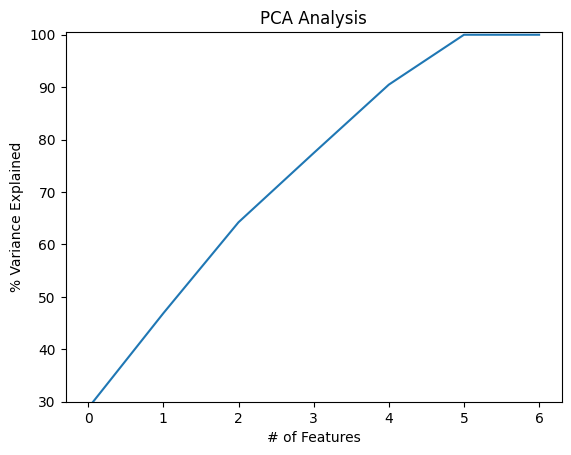

In [ ]:
plt.ylabel('% Variance Explained')
plt.xlabel('# of Features')
plt.title('PCA Analysis')
plt.ylim(30,100.5)
plt.style.context('seaborn-whitegrid')
plt.plot(var)
plt.show()

The Cumulative % gives the percentage of variance accounted for by the n components. For example, the cumulative percentage for the second component is the sum of the percentage of variance for the first and second components. It helps in deciding the number of components by selecting the components which explained the variance required.

In the above array we see that the first feature explains 46% of the variance within our data set while the first two explain 64 and so on. If we use 5 features we capture 99% of the variance within the dataset.

In [ ]:
train_pca_data_5 = train_pca_data.iloc[:,:5] #selecting 5 PCs

In [ ]:
test_pca_data_5 = test_pca_data.iloc[:,:5]  #selecting 5 PCs

In [ ]:
train_pca_data_5.shape

(219, 5)

In [ ]:
train_pca_data_5.corr().round(2)

,PC1,PC2,PC3,PC4,PC5
PC1,1.0,-0.0,-0.0,0.0,-0.0
PC2,-0.0,1.0,-0.0,-0.0,-0.0
PC3,-0.0,-0.0,1.0,-0.0,-0.0
PC4,0.0,-0.0,-0.0,1.0,0.0
PC5,-0.0,-0.0,-0.0,0.0,1.0


Now that we have obtained Principal Components with No correlations among them, we shall use them to train Linear Regression Model.

#### Linear Regression Model using the chosen 5 Principal Components -

In [ ]:
LR_pca = LinearRegression()
LR_pca.fit(train_pca_data_5,y_train)

LinearRegression()

In [ ]:
y_train_pred_pca = LR_pca.predict(train_pca_data_5)

In [ ]:
y_test_pred_pca = LR_pca.predict(test_pca_data_5)

### RMSE values -

In [ ]:
np.sqrt(mean_squared_error(y_true = y_train, y_pred =y_train_pred_pca )).round(3)

0.506

In [ ]:
np.sqrt(mean_squared_error(y_true = y_test, y_pred =y_test_pred_pca )).round(3)

0.428

### R^2 Scores -

In [ ]:
r2_score(y_true = y_train, y_pred =y_train_pred_pca )

0.2614134163503148

In [ ]:
r2_score(y_true = y_test, y_pred =y_test_pred_pca )

0.4001122266155166

### Adj. R2 Scores -

<img src="http://www.haghish.com/statistics/stata-blog/stata-programming/images/adjr2.png" width="400" height="200" />

In [ ]:
n = train_pca_data_5.shape[0]
k = train_pca_data_5.shape[1]
r2 = r2_score(y_true = y_train, y_pred =y_train_pred_pca )

In [ ]:
1 - ((1- r2)*(n-1)/(n-k-1))

0.24407570311910154

In [ ]:
n = test_pca_data_5.shape[0]
k = test_pca_data_5.shape[1]
r2 = r2_score(y_true = y_test, y_pred =y_test_pred_pca )

In [ ]:
1 - ((1- r2)*(n-1)/(n-k-1))

0.23347673400871571

#### Conclusion -

We have obtained a very similar R2 scores (and Adj. R2) of 0.23 and 0.24 on both Train and Test set, when compared to  the first model(LR with original features).We observe that even after reducing the number of predictors by approximately 30% , the model performance did not deteriorate. This shows us the strength of PCA, PCA was successfully used to reduce the noise from the dataset, without compromising with the model performance. It also reomved the multicollinearity present in the original dataset.
